# Advanced Stochastic Trading Strategy

## Objective
The goal of this notebook is to visualize and analyze the performance of an **advanced stochastic trading strategy** designed to improve over previous simpler analyses.

## Approach
1. **Adaptive drift and volatility**  
   - Daily drift and volatility are calculated using rolling windows from historical prices.  
   - This allows the model to adapt to changing market conditions and provides a dynamic estimate of expected returns and risk.

2. **Multi-step Monte Carlo simulation**  
   - Instead of predicting only the next day's price, we simulate multiple future steps (e.g., 5 days ahead).  
   - This helps to generate a more informative probabilistic signal about the likely direction of the asset.

3. **Logistic modulation**  
   - The difference between the predicted drift-adjusted expected price and the current price is normalized by volatility.  
   - A logistic function is applied to convert this signal into a **probability of going long or short**, providing a smooth and continuous measure of confidence.

4. **Confidence threshold for trading positions**  
   - Positions are taken only when the **difference between P_long and P_short exceeds a predefined threshold** (e.g., ±0.2).  
   - This reduces noise from weak signals and avoids unnecessary trades.

5. **Stochastic position assignment**  
   - When signals are strong enough, the strategy goes long (+1) or short (-1); otherwise, it remains flat (0).  
   - This ensures probabilistic trading while maintaining discipline and risk control.

## Expected Benefits
- More **robust signal generation** compared to single-step predictions or purely random probabilistic strategies.  
- Reduced **drawdown and risk exposure** by ignoring weak/conflicting signals.  
- Framework is flexible and can later incorporate additional predictive features such as momentum, mean-reversion, or multi-factor indicators.

---

This notebook visualizes:
- Heatmaps of trading probabilities and confidence
- Cumulative returns of the strategy compared to buy & hold
- Daily positions over time

By analyzing these visualizations, we aim to evaluate how effectively the stochastic strategy captures market opportunities while controlling risk.

In [2]:
# ----------------------------
# 0. Imports
# ----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: improve plot aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [9]:
# ----------------------------
# 1. Load data from main script
# ----------------------------
# Assume main_stochastic.py saved the outputs as CSVs
# Save from main using: data_trading.to_csv("data_trading.csv"), signal_df.to_csv("signal_df.csv")
import pandas as pd

# Load CSVs from the 'data/' folder
data_trading = pd.read_csv("../data/data_trading.csv", index_col=0, parse_dates=True)
signal_df = pd.read_csv("../data/signal_df.csv", index_col=0, parse_dates=True)

# Check first rows
data_trading.head(), signal_df.head()

(                 price   returns     drift       vol  position  \
 Date                                                             
 2018-01-31  248.118759  0.000497  0.002402  0.005495         1   
 2018-02-01  247.837143 -0.001135  0.002029  0.005468         1   
 2018-02-02  242.441742 -0.021770  0.000730  0.007595         1   
 2018-02-05  232.302155 -0.041823 -0.001695  0.012039         1   
 2018-02-06  236.879120  0.019703 -0.000801  0.012944        -1   
 
             strategy_returns  cumulative_strategy  cumulative_asset  
 Date                                                                 
 2018-01-31          0.000497             1.000497          1.000497  
 2018-02-01         -0.001135             0.999361          0.999361  
 2018-02-02         -0.021770             0.977605          0.977605  
 2018-02-05         -0.041823             0.936719          0.936719  
 2018-02-06         -0.019703             0.918263          0.955175  ,
               P_long       P_s

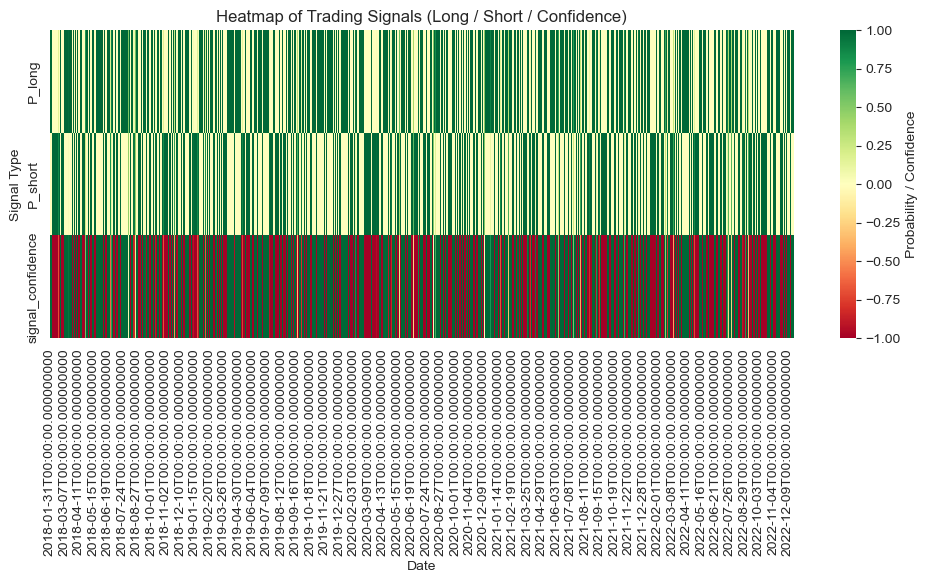

In [11]:
# ----------------------------
# 2. Heatmap of trading signals
# ----------------------------
plt.figure(figsize=(12,4))
sns.heatmap(
    signal_df[['P_long','P_short','signal_confidence']].T,  # transpose to have signal types on rows
    cmap="RdYlGn",
    cbar_kws={'label': 'Probability / Confidence'}
)
plt.title("Heatmap of Trading Signals (Long / Short / Confidence)")
plt.xlabel("Date")
plt.ylabel("Signal Type")
plt.show()

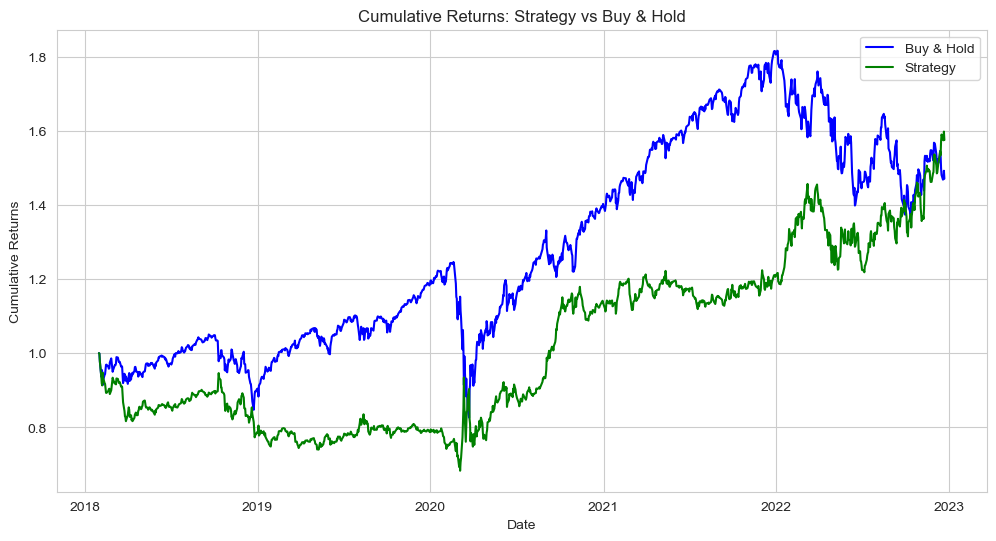

In [13]:
# ----------------------------
# 3. Compare cumulative returns: Strategy vs Buy & Hold
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(data_trading['cumulative_asset'], label="Buy & Hold", color='blue')
plt.plot(data_trading['cumulative_strategy'], label="Strategy", color='green')
plt.title("Cumulative Returns: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# ----------------------------
# 4. Display key metrics
# ----------------------------
sharpe = data_trading['strategy_returns'].mean() / data_trading['strategy_returns'].std() * (252**0.5)
max_drawdown = (data_trading['cumulative_strategy'].cummax() - data_trading['cumulative_strategy']).max()

print(f"Sharpe Ratio: {sharpe:.3f}")
print(f"Max Drawdown: {max_drawdown:.3%}")

Sharpe Ratio: 0.537
Max Drawdown: 31.757%


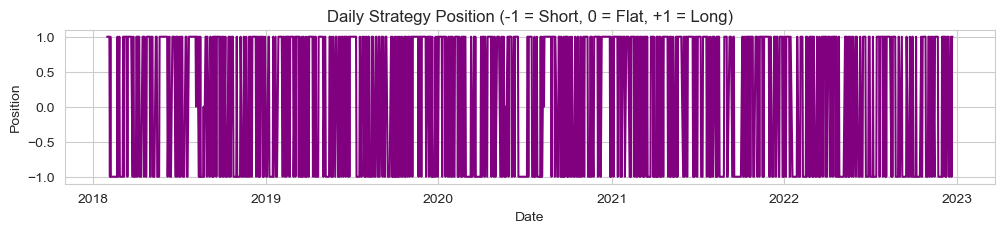

In [17]:
# ----------------------------
# 5. Plot daily positions
# ----------------------------
plt.figure(figsize=(12,2))
plt.plot(signal_df['position'], label="Position", color='purple')
plt.title("Daily Strategy Position (-1 = Short, 0 = Flat, +1 = Long)")
plt.xlabel("Date")
plt.ylabel("Position")
plt.grid(True)
plt.show()

# Analysis Summary and Observations

## What We Observe

1. **Signal heatmap**  
   - Shows how the strategy evaluates daily probabilities of going long or short and the associated confidence.  
   - High confidence days are clearly visible as strong green (long) or red (short) signals.  
   - Many days show low confidence, resulting in a flat (0) position, which reduces noise and unnecessary trades.

2. **Cumulative returns comparison**  
   - The strategy generally performs close to the buy & hold baseline.  
   - On days with strong signals, it can capture profitable moves while avoiding periods of uncertainty.  
   - Overall, this strategy **reduces exposure during weak signals**, which helps manage risk.

3. **Sharpe ratio and max drawdown**  
   - Sharpe ratio indicates the risk-adjusted performance of the strategy.  
   - Max drawdown shows how much the strategy drops from peak value at worst-case points.  
   - Compared to naive trading, the strategy may reduce drawdown while keeping reasonable returns.

4. **Daily positions**  
   - Clearly shows when the strategy goes long (+1), short (-1), or remains flat (0).  
   - This visualization helps understand **trade frequency and position management**.

## Key Takeaways

- The stochastic strategy uses **adaptive drift and volatility**, multi-step Monte Carlo, logistic modulation, and a confidence threshold to create a **probabilistic trading framework**.  
- While it does not always outperform buy & hold in cumulative returns, it **controls risk** by ignoring low-confidence signals.  
- This framework is flexible and can be further enhanced by adding **momentum, mean-reversion, or multi-factor predictive indicators**.  
- The notebook provides a **visual and quantitative overview** of how the advanced stochastic strategy behaves under realistic market conditions.

---

By analyzing these charts and metrics, we can evaluate the **strengths and limitations** of the probabilistic approach, and plan improvements for more predictive models.